## PR2610: Analiza dirk Formule 1
### Projektna naloga pri predmetu Podatkovno Rudarjenje

In [1]:
# pip install fastf1
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import matplotlib.colors as mcolors
from fastf1.plotting import get_team_color
import warnings
warnings.filterwarnings("ignore")

/home/markh/miniconda3/envs/PRvaje/lib/python3.14/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
fastf1.Cache.enable_cache('./cache')
# plotting.setup_mpl(mpl_timedelta_support=True, color_scheme='fastf1')

### Nastavitve podatkov

In [3]:
# Nastavitve
# Sezona
SEASON = 2025
# Dirke
schedule = fastf1.get_event_schedule(SEASON)
num_races = schedule['RoundNumber'].max()
RACES = range(1, num_races + 1) # Kot številke 1, 2, 3 ... drugače v race_names = ["Australia", "Japan", ...]

race_names = [
    schedule[schedule['RoundNumber'] == r]['EventName'].values[0]
    for r in RACES
]

RACES = race_names
# RACES = ["Australian", "British"]

DRIVERS = None  # None = vsi
COMPOUND_COLORS = {
    'SOFT':   '#E12319',
    'MEDIUM': '#FFEF00',
    'HARD':   '#FFFFFF',
    'INTERMEDIATE':  '#39B54A',
    'WET':    '#0067FF',
}
PRIMARY_TYRES = ['SOFT', 'MEDIUM', 'HARD']
ALL_TYRES = ['SOFT','MEDIUM', 'HARD', 'INTERMEDIATE', 'WET']
DRY_LAPS_ONLY = False # ali zelimo primerjati samo suhe ali pa vse
CHOSEN_TYRES = (PRIMARY_TYRES if DRY_LAPS_ONLY else ALL_TYRES)


MIN_LAPS_FOR_FIT = 5    # najmanjše število krogov za regresijsko premico

COLORS = plt.cm.tab20.colors  # ali 'tab20' za več dirk 'tab10' za manj
RACE_COLORS = {race: COLORS[i % len(COLORS)] for i, race in enumerate(RACES)}

### Rezultati izbrane sezone

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
core           INFO 	Finished loading data for 20 drivers: ['4', '1', '63', '12', '23', '18', '27', '16', '81', '44', '10', '22', '31', '87', '30', '5', '14', '55', '7', '6']
core           INFO 	Loading data for Chinese Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
core           INFO 	Finished loading data for 20 drivers: ['81', '4', '63', '1', '31', '12', '23', '87', '18', '55', '6', '30', '7', '5', '27', '22', '14', '16', '44', '10'

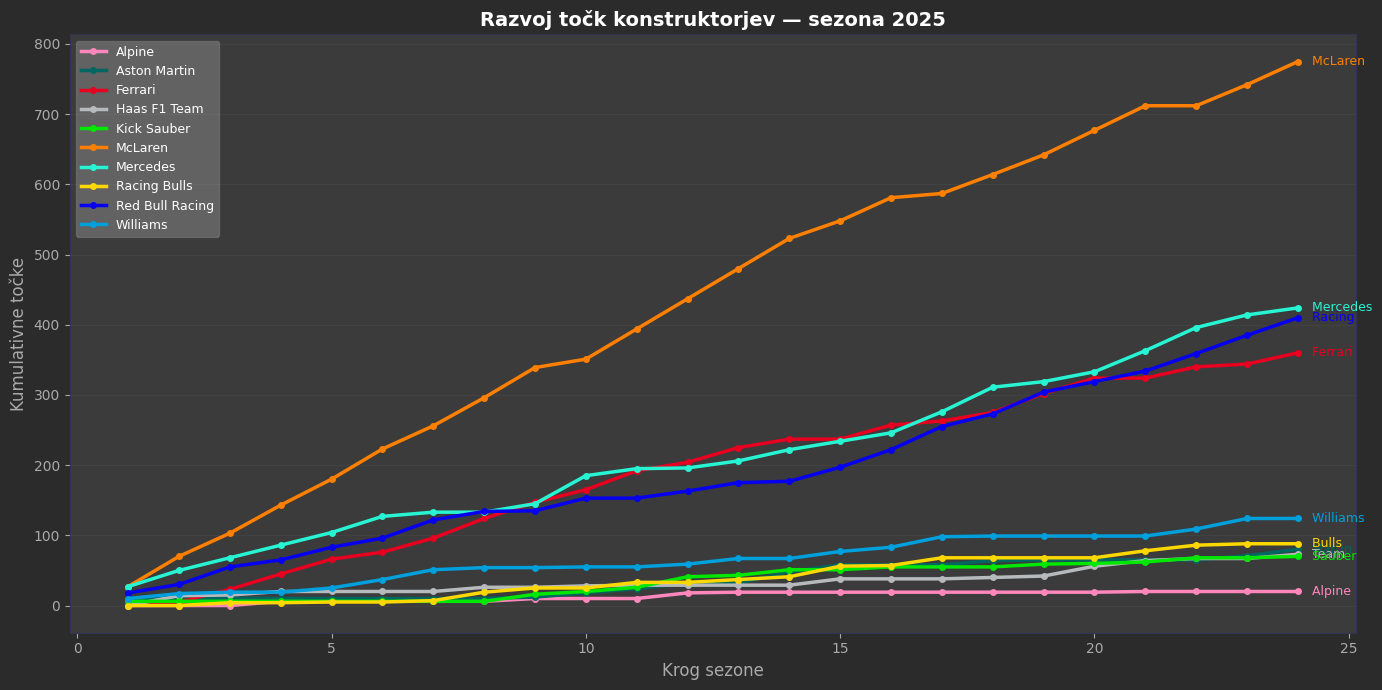

In [4]:
# Kumulativne točke konstruktorjev
points_rows = []
for race in RACES:
    try:
        session = fastf1.get_session(SEASON, race, 'R')
        session.load(laps=False, telemetry=False, weather=False, messages=False)
        res = session.results[['TeamName', 'Points']].copy()
        res['Race'] = race
        res['RoundNumber'] = list(RACES).index(race) + 1
        points_rows.append(res)
    except Exception as e:
        print(f"Error: {e}")

df_points = pd.concat(points_rows, ignore_index=True)

team_pts = (df_points
    .groupby(['RoundNumber', 'Race', 'TeamName'])['Points']
    .sum()
    .reset_index()
    .sort_values('RoundNumber')
)
team_pts['CumulativePoints'] = team_pts.groupby('TeamName')['Points'].cumsum()

team_results = (team_pts.groupby('TeamName')['Points']
        .sum().index.tolist())

# Barve ekip
try:
    team_colors = {t: get_team_color(t, session=fastf1.get_session(SEASON, 1, 'R')) for t in team_results}
except:
    cmap = plt.cm.tab20.colors
    team_colors = {t: cmap[i % len(cmap)] for i, t in enumerate(team_results)}

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor("#2B2B2B")
ax.set_facecolor("#3B3B3B")

for team in team_results:
    d = team_pts[team_pts['TeamName'] == team]
    color = team_colors.get(team, '#888888')
    ax.plot(d['RoundNumber'], d['CumulativePoints'],
            color=color, linewidth=2.5, marker='o', markersize=4, label=team)
    last = d.iloc[-1]
    ax.text(last['RoundNumber'] + 0.2, last['CumulativePoints'],
            f" {team.split()[-1]}", color=color, fontsize=9, va='center')

ax.set_xlabel('Krog sezone', color='#aaaaaa', fontsize=12)
ax.set_ylabel('Kumulativne točke', color='#aaaaaa', fontsize=12)
ax.set_title(f'Razvoj točk konstruktorjev — sezona {SEASON}',
             color='white', fontsize=14, fontweight='bold')
ax.tick_params(colors='#aaaaaa')
ax.spines[:].set_color('#333355')
ax.yaxis.grid(True, alpha=0.3, color='#555555')
ax.set_axisbelow(True)
ax.legend(fontsize=9, framealpha=0.2, labelcolor='white')

plt.tight_layout()
plt.show()


Iz grafa je razvidna dominanca ekipe McLaren, sledili so Mercedes, Red Bull Racing ter Ferrari, za zadnja mesta so se borili ostali.

## Degradacija gum

Naložimo in obdelamo podatke - odstanimo vse nečiste kroge dirkačev (Varnostni avto, postanek za menjavo gum, ...). Odstranimo tudi osamelce, ki odstopajo za več kot 3 standardne odklone od mediane.

In [5]:

# Funkcije
def load_race_laps(season: int, race_name: str) -> pd.DataFrame:
    """Naloži in filtrira kroge ene dirke"""
    session = fastf1.get_session(season, race_name, 'R')
    session.load(laps=True, weather=False, telemetry=False, messages=False)

    laps = session.laps.copy()

    # Ohrani samo veljavne, natančne kroge (brez SC, VSC, pit in/out)
    laps = laps.pick_accurate()
    laps = laps[laps['PitOutTime'].isna() & laps['PitInTime'].isna()]

    # Pretvori LapTime v sekunde
    laps['LapTime_s'] = laps['LapTime'].dt.total_seconds()

    # Odstrani osamelce (> 3σ od mediane za vsako trdoto)
    def remove_outliers(group):
        med = group['LapTime_s'].median()
        sd  = group['LapTime_s'].std()
        return group[np.abs(group['LapTime_s'] - med) < 3 * sd]

    laps = laps.groupby('Compound', group_keys=False).apply(remove_outliers)

    laps['Race'] = race_name
    laps['Season'] = season

    # Ohrani samo pomebne stolpce
    keep = ['Race', 'Season', 'Driver', 'Team', 'LapNumber',
            'Compound', 'TyreLife', 'LapTime_s']
    return laps[[c for c in keep if c in laps.columns]].dropna(subset=['LapTime_s', 'TyreLife'])

# Naredimo regresijsko premico
def degradation_slope(group: pd.DataFrame) -> float:
    """Vrne naklon linearne regresije LapTime/TyreLife (s/krog)."""
    if len(group) < MIN_LAPS_FOR_FIT:
        return np.nan
    slope, *_ = stats.linregress(group['TyreLife'], group['LapTime_s'])
    return slope

# Nalaganje podatkov
all_laps = []
for race in RACES:
    try:
        df = load_race_laps(SEASON, race)
        all_laps.append(df)
    except Exception as e:
        print(f"NAPAKA: {e}")

if not all_laps:
    raise RuntimeError("Ni bilo mogoče naložiti nobene dirke.")

laps_all = pd.concat(all_laps, ignore_index=True)

# Filtriraj voznike
if DRIVERS:
    laps_all = laps_all[laps_all['Driver'].isin(DRIVERS)]


# Ohrani samo osnovne (brez INT/WET ko ni dež)
laps_dry = laps_all[laps_all['Compound'].isin(CHOSEN_TYRES)].copy()

unique_tyres_num = len(laps_dry['Compound'].unique())
print(f"\nSkupaj krogov: {len(laps_all)}")
print(f"Spojine: {unique_tyres_num}")

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data fo


Skupaj krogov: 22428
Spojine: 4


### Grafi za prikaz spremembe časa kroga glede na starost gum po dirkah. 

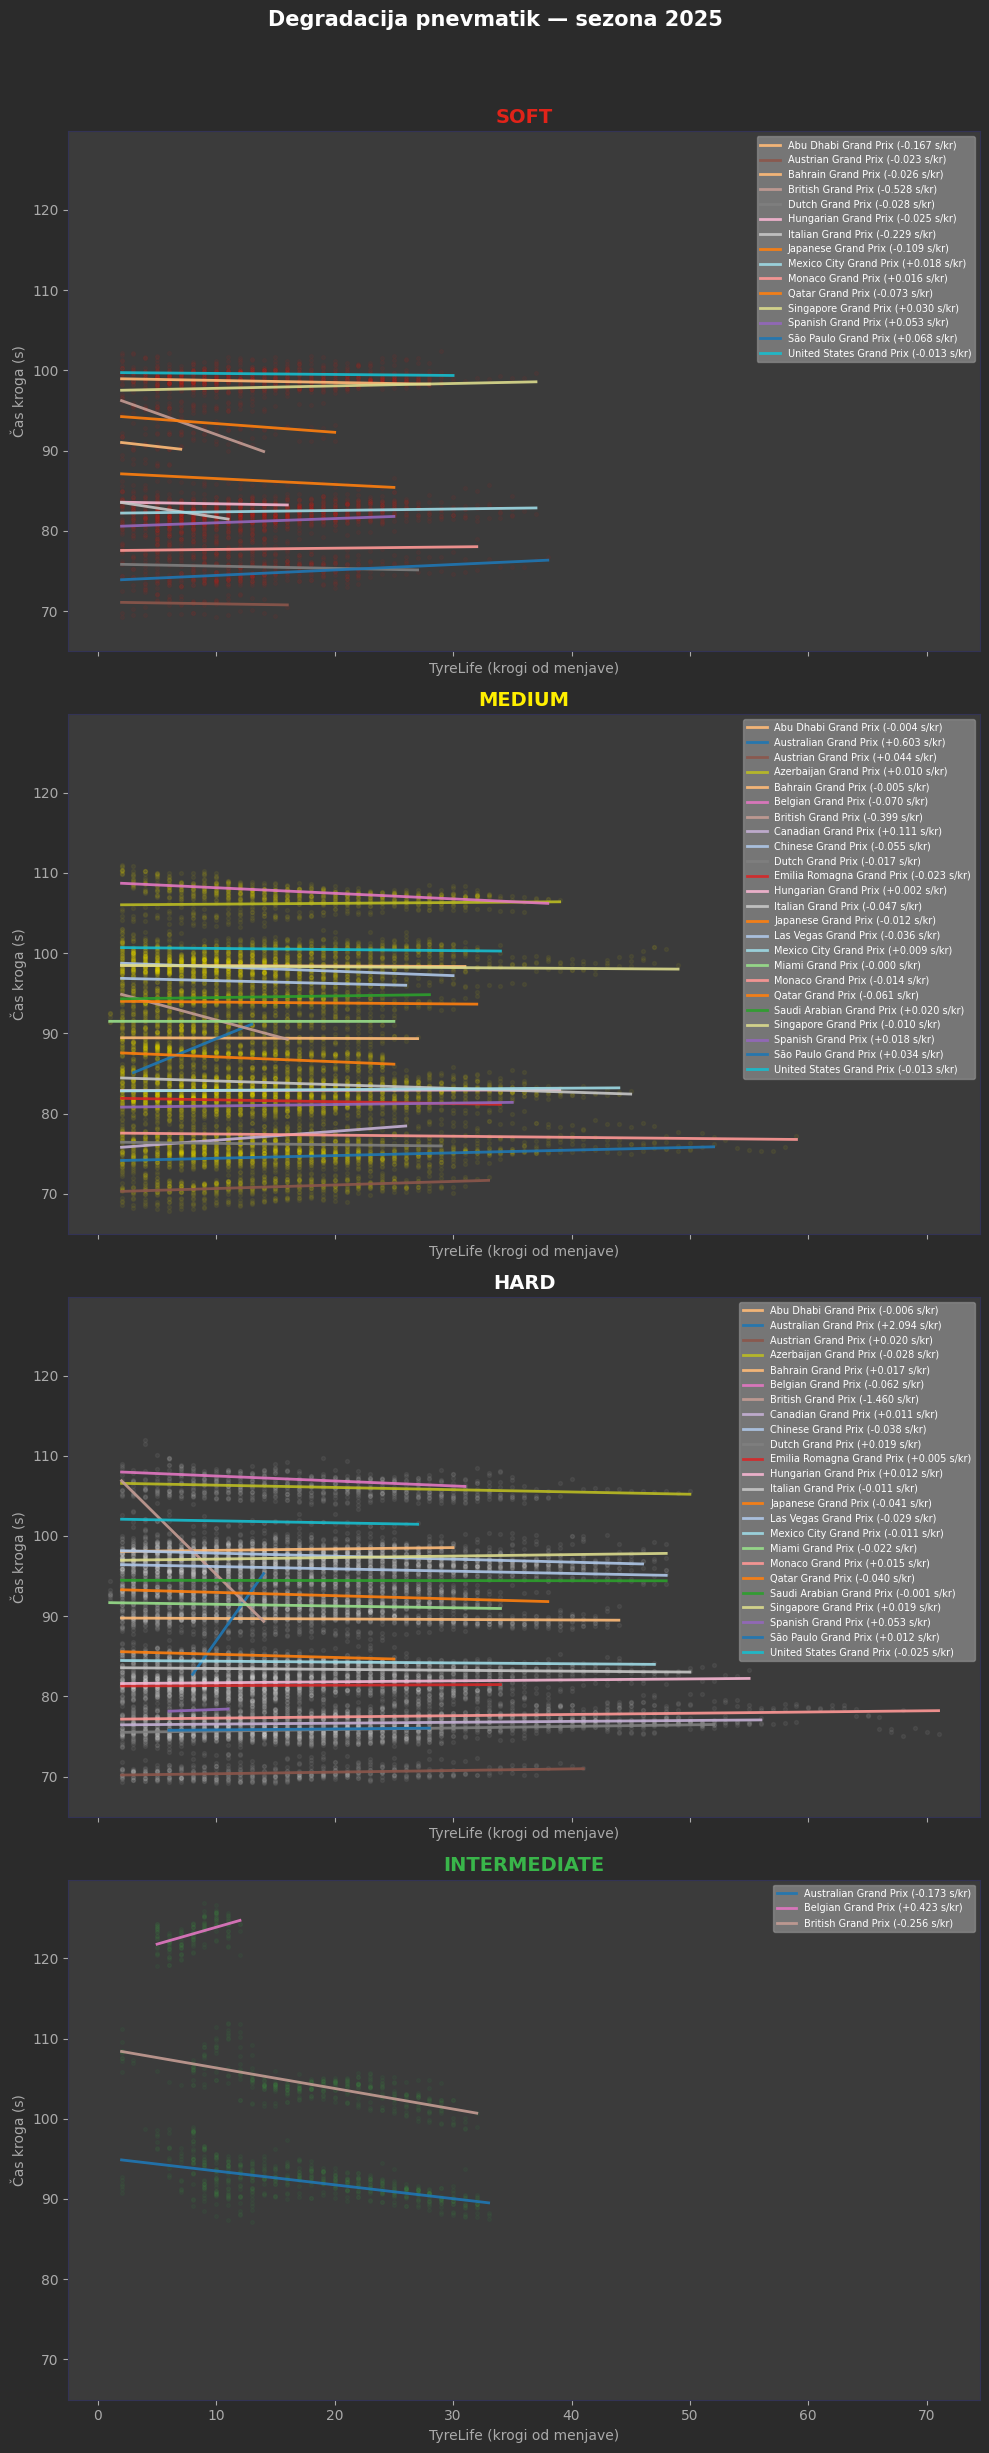

In [6]:
# Graf 1: Degradacija po spojini (vse dirke skupaj)
fig, axes = plt.subplots( unique_tyres_num,1, figsize=(10, 6 * unique_tyres_num), sharey=True, sharex=True)

for ax, compound in zip(axes,CHOSEN_TYRES):
    data = laps_dry[laps_dry['Compound'] == compound]
    color = COMPOUND_COLORS[compound]
    text_color = '#1a1a2e' if compound == 'HARD' else color

    # Scatter: posamezni krogi
    ax.scatter(data['TyreLife'], data['LapTime_s'],
               alpha=0.05, s=8, color=color, zorder=2)

    # Po dirki: barvni trend
    for race, rdf in data.groupby('Race'):
        if len(rdf) < MIN_LAPS_FOR_FIT:
            continue
        x = rdf['TyreLife'].values
        y = rdf['LapTime_s'].values
        m, b, r, p, _ = stats.linregress(x, y)
        xfit = np.linspace(x.min(), x.max(), 50)
        ax.plot(xfit, m * xfit + b, alpha=0.9, lw=2, color=RACE_COLORS[race],
                label=f'{race} ({m:+.3f} s/kr)')
  
    # # Skupna regresija
    # if len(data) >= MIN_LAPS_FOR_FIT:
    #     m, b, r, p, _ = stats.linregress(data['TyreLife'], data['LapTime_s'])
    #     xfit = np.linspace(data['TyreLife'].min(), data['TyreLife'].max(), 100)
    #     ax.plot(xfit, m * xfit + b, color=color, lw=2.5, zorder=5,
    #             label=f'Skupaj: {m:+.3f} s/kr (R²={r**2:.2f})')

    ax.set_title(compound, color=color, fontsize=14, fontweight='bold')
    ax.set_xlabel('TyreLife (krogi od menjave)', color='#aaaaaa')
    ax.set_ylabel('Čas kroga (s)', color='#aaaaaa')
    ax.tick_params(colors='#aaaaaa')
    ax.spines[:].set_color('#333355')
    ax.legend(fontsize=7, framealpha=0.3, labelcolor='white')
    ax.set_facecolor("#3B3B3B")

fig.suptitle(f'Degradacija pnevmatik — sezona {SEASON}',
             color='white', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
fig.patch.set_facecolor("#2B2B2B")
plt.show()

Na grafih vidimo, da so `soft` gume uporabljali manj, saj so tudi zdržale manj kot `medium` in `hard`. Vidimo tudi nekaj nenavadnih regresijskih premic (<a href="https://www.youtube.com/watch?v=md9-jG4RzXs">Australian Grand Prix</a> in <a href="https://www.youtube.com/watch?v=daWr9xnkKS4">British Grand Prix</a>). Razlog za to so bile vremenske razmere in posledično strategije menjav gum.

### Graf heatmap za prikaz spremembe povprečnega časa na krog za različne trdote in dirke.

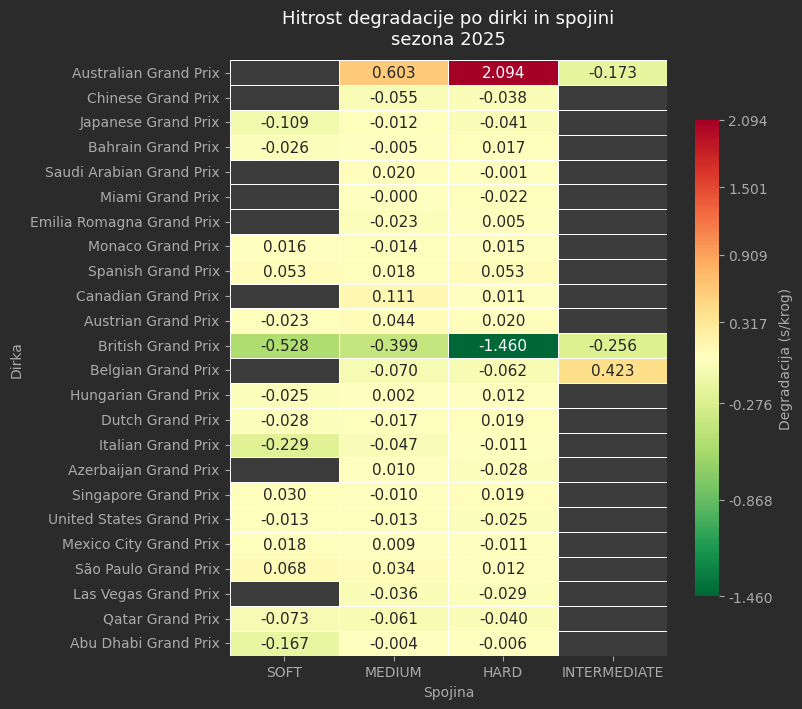

In [7]:
# Graf 2: Heatmap naklonov degradacije (spojina × dirka)
slopes = (
    laps_dry
    .groupby(['Race', 'Compound'])
    .apply(degradation_slope)
    .reset_index(name='Slope_s_per_lap')
)

pivot = slopes.pivot(index='Race', columns='Compound', values='Slope_s_per_lap')
pivot = pivot.reindex(columns=[c for c in CHOSEN_TYRES if c in pivot.columns])
pivot = pivot.reindex(RACES)   # ohrani vrstni red dirk

fig, ax = plt.subplots(figsize=(8, max(4, len(RACES) * 0.3)))

vmin = pivot.min().min()
vmax = pivot.max().max()

norm = mcolors.TwoSlopeNorm(
    vmin=vmin,
    vcenter=0,
    vmax=vmax
)

sns.heatmap(
    pivot,
    annot=True, fmt='.3f', linewidths=0.5,
    cmap='RdYlGn_r',   # rdeča = hitra degradacija, zelena = počasna
    norm=norm,
    ax=ax,
    cbar_kws={'label': 'Degradacija (s/krog)', 'shrink': 0.8},
    annot_kws={'size': 11}
)
cbar = ax.collections[0].colorbar
cbar.set_label('Degradacija (s/krog)', color='#aaaaaa')
cbar.ax.tick_params(colors='#aaaaaa')
ticks = np.linspace(vmin, vmax, 7)
cbar.set_ticks(ticks)
cbar.set_ticklabels([f"{t:.3f}" for t in ticks])

ax.set_title(f'Hitrost degradacije po dirki in spojini\nsezona {SEASON}',
             color='white', fontsize=13, pad=12)
ax.set_xlabel('Spojina', color='#aaaaaa')
ax.set_ylabel('Dirka', color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
ax.set_facecolor("#3B3B3B")

plt.tight_layout()
fig.patch.set_facecolor("#2B2B2B")
plt.show()

Opazno je, da večinoma ni pretirane razlike med krogi, razen pri Australian in British Grand Prix zaradi prej omenjenih vremenskih sprememb.

### Graf primerjave med vozniki za dirko z največ podatki

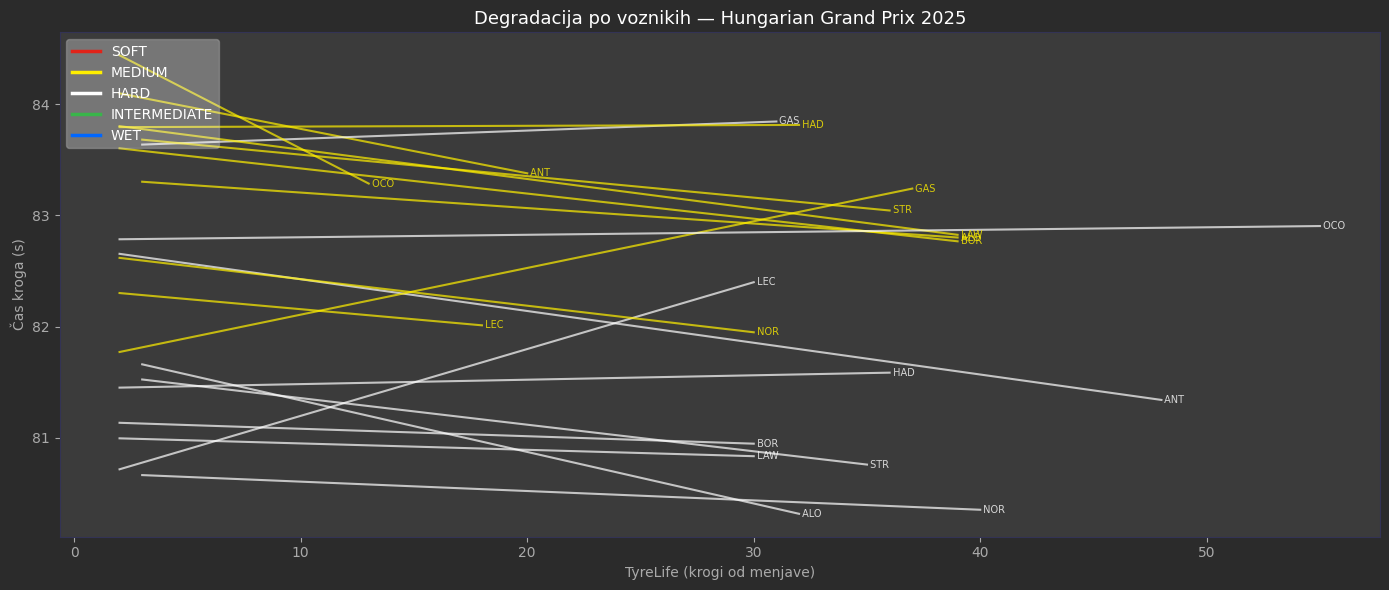

In [8]:
# Graf 3: Primerjava med vozniki
# Vzami dirko z največ podatki
best_race = laps_dry.groupby('Race').size().idxmax()
race_data = laps_dry[laps_dry['Race'] == best_race]

# Top 10 voznikov po številu krogov
top_drivers = race_data.groupby('Driver').size().nlargest(10).index
race_data = race_data[race_data['Driver'].isin(top_drivers)]

fig, ax = plt.subplots(figsize=(14, 6))

for driver, ddf in race_data.groupby('Driver'):
    for compound, cdf in ddf.groupby('Compound'):
        if len(cdf) < MIN_LAPS_FOR_FIT:
            continue
        m, b, r, p, _ = stats.linregress(cdf['TyreLife'], cdf['LapTime_s'])
        xfit = np.linspace(cdf['TyreLife'].min(), cdf['TyreLife'].max(), 50)
        ax.plot(xfit, m * xfit + b,
                color=COMPOUND_COLORS[compound], alpha=0.7, lw=1.5)
        ax.text(xfit[-1], m * xfit[-1] + b, f' {driver}',
                fontsize=7, color=COMPOUND_COLORS[compound], va='center', alpha=0.8)

# Legenda
for comp, col in COMPOUND_COLORS.items():
    if comp in CHOSEN_TYRES:
        ax.plot([], [], color=col, lw=2.5, label=comp)
ax.legend(loc='upper left', framealpha=0.3, labelcolor='white')

ax.set_title(f'Degradacija po voznikih — {best_race} {SEASON}',
             color='white', fontsize=13)
ax.set_xlabel('TyreLife (krogi od menjave)', color='#aaaaaa')
ax.set_ylabel('Čas kroga (s)', color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
ax.spines[:].set_color('#333355')
ax.set_facecolor("#3B3B3B")

plt.tight_layout()
fig.patch.set_facecolor("#2B2B2B")
plt.show()

Iz grafa je razvidno, da so bile na prikazani dirki `hard` gume hitrejše od `medium`.

In [9]:
# Povzetek
print("Povprečna degradacija po spojini (s/krog)")
print(slopes.groupby('Compound')['Slope_s_per_lap']
      .agg(['mean', 'std', 'min', 'max'])
      .round(4)
      .to_string())

print("\nNajhitrejša in najpočasnejša degradacija po dirki")

worst = slopes.loc[slopes.groupby('Race')['Slope_s_per_lap'].idxmax()]
best  = slopes.loc[slopes.groupby('Race')['Slope_s_per_lap'].idxmin()]

worst = worst.rename(columns={'Slope_s_per_lap': 'Najslabša degredacija', 'Compound': 'Najslabša trdota'})
best = best.rename(columns={'Slope_s_per_lap': 'Najboljša degredacija', 'Compound': 'Najboljša trdota'})

best_worst = worst.merge(best, on='Race')
best_worst = best_worst.rename(columns={'Race': 'Dirka'})

print(best_worst[['Dirka', 'Najslabša trdota', 'Najslabša degredacija', 'Najboljša trdota', 'Najboljša degredacija']].to_string(index=False))


Povprečna degradacija po spojini (s/krog)
                mean     std     min     max
Compound                                    
HARD          0.0210  0.5325 -1.4602  2.0937
INTERMEDIATE -0.0020  0.3704 -0.2564  0.4230
MEDIUM        0.0035  0.1555 -0.3995  0.6032
SOFT         -0.0691  0.1504 -0.5280  0.0678

Najhitrejša in najpočasnejša degradacija po dirki
                    Dirka Najslabša trdota  Najslabša degredacija Najboljša trdota  Najboljša degredacija
     Abu Dhabi Grand Prix           MEDIUM              -0.004250             SOFT              -0.167251
    Australian Grand Prix             HARD               2.093713     INTERMEDIATE              -0.172620
      Austrian Grand Prix           MEDIUM               0.044309             SOFT              -0.022610
    Azerbaijan Grand Prix           MEDIUM               0.010169             HARD              -0.028282
       Bahrain Grand Prix             HARD               0.017109             SOFT              -0.025706
 

## Primerjave proizvajalcev

In [10]:
# Normalizacija časov (% od najhitrejšega kroga v tej dirki)
def normalize_laptime(group):
    fastest = group['LapTime_s'].min()
    group['LapTimePct'] = (group['LapTime_s'] / fastest - 1) * 100
    return group

laps_teams = laps_dry.groupby('Race', group_keys=False).apply(normalize_laptime)

# Povprečje po ekipi čez vse dirke
team_overall = (laps_teams
    .groupby('Team')
    .agg(
        MedianPct = ('LapTimePct', 'median'),
        StdPct    = ('LapTimePct', 'std'),
        LapCount  = ('LapTimePct', 'count'),
    )
    .reset_index()
    .sort_values('MedianPct')
)
print(team_overall.to_string(index=False))

           Team  MedianPct   StdPct  LapCount
        McLaren   2.507364 2.711833      2387
        Ferrari   2.929709 3.047562      2302
       Mercedes   3.049186 2.961210      2298
Red Bull Racing   3.180539 3.188793      2324
       Williams   3.824902 3.088262      2123
   Racing Bulls   3.973272 2.294824      2243
   Aston Martin   4.009878 2.973054      2140
   Haas F1 Team   4.053697 3.140623      2339
         Alpine   4.249648 2.537987      2178
    Kick Sauber   4.260918 2.763982      2094


Iz izpisa se vidi, da je bila ekila McLaren povprečno najbližje najhitrejšem krogu dirke. Bili so tudi najbolj konsistentni (StdPct). Najmanj konsistentna je bila ekipa Mercedes.

### Škatla z brki za povprečno odstopanje od najhitrejše kroga dirk

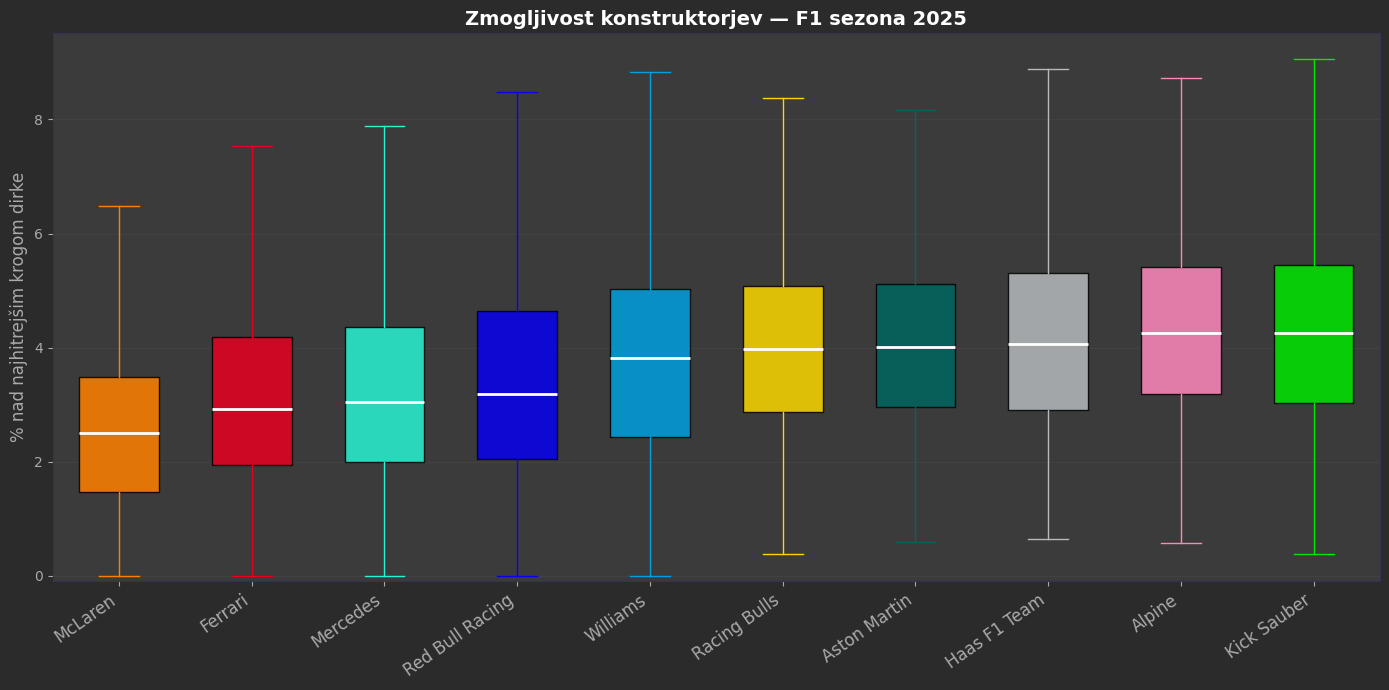

In [11]:

# Graf 1: Box plot po ekipah
team_order = team_overall['Team'].tolist()

# Barve ekip
try:
    team_colors = {t: get_team_color(t, session=fastf1.get_session(SEASON, 1, 'R')) for t in team_order}
except:
    cmap = plt.cm.tab20.colors
    team_colors = {t: cmap[i % len(cmap)] for i, t in enumerate(team_order)}

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor("#2B2B2B")
ax.set_facecolor("#3B3B3B")

for i, team in enumerate(team_order):
    data = laps_teams[laps_teams['Team'] == team]['LapTimePct']
    color = team_colors.get(team, '#888888')
    ax.boxplot(
        data,
        positions=[i],
        widths=0.6,
        patch_artist=True,
        showfliers=False, # True, da vidiš osamelce (mogoče uporabno)
        medianprops={'color':'white', 'linewidth':2},
        boxprops={'facecolor':color, 'alpha':0.85},
        whiskerprops={'color':color},
        capprops={'color':color},
    )

ax.set_xticks(range(len(team_order)))
ax.set_xticklabels(team_order, rotation=35, ha='right', fontsize=12, color='#aaaaaa')
ax.set_ylabel('% nad najhitrejšim krogom dirke', color='#aaaaaa', fontsize=12)
ax.set_title(f'Zmogljivost konstruktorjev — F1 sezona {SEASON}',
             color='white', fontsize=14, fontweight='bold')
ax.tick_params(colors='#aaaaaa')
ax.spines[:].set_color('#333355')
ax.yaxis.grid(True, alpha=0.3, color='#555555')
ax.set_axisbelow(True)
ax.set_ylim(bottom=-0.1)

plt.tight_layout()
plt.show()


### Graf heatmap za prikaz odstopanje ekipe od najhitrejšega kroga za posamezno dirko

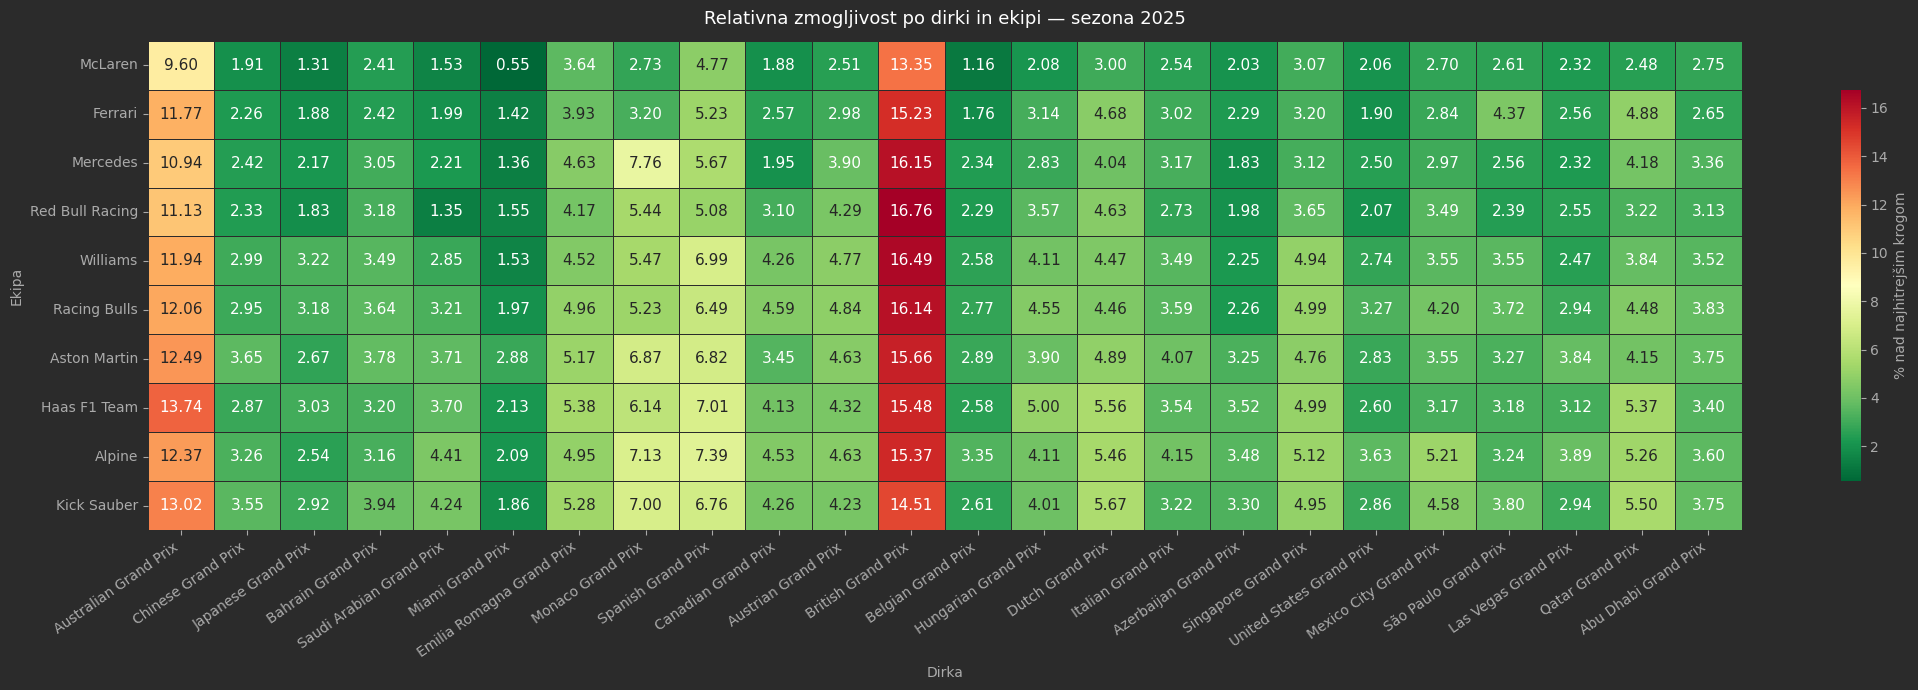

In [12]:
# Graf 2: Heatmap ekipa / dirka
team_race_median = (laps_teams
    .groupby(['Team', 'Race'])['LapTimePct']
    .median()
    .reset_index()
)

pivot = team_race_median.pivot(index='Team', columns='Race', values='LapTimePct')

# Uredi vrstice po mediani, stolpce po vrstnem redu dirk
pivot = pivot.loc[team_order]
ordered_cols = [r for r in RACES if r in pivot.columns]
pivot = pivot[ordered_cols]

fig, ax = plt.subplots(figsize=(max(12, len(ordered_cols) * 0.9), 7))
fig.patch.set_facecolor("#2B2B2B")
ax.set_facecolor("#3B3B3B")

sns.heatmap(
    pivot,
    ax=ax,
    cmap='RdYlGn_r',
    annot=True, fmt='.2f',
    linewidths=0.4, linecolor='#2B2B2B',
    cbar_kws={'label': '% nad najhitrejšim krogom', 'shrink': 0.8},
    annot_kws={'size': 11}
)

cbar = ax.collections[0].colorbar
cbar.set_label('% nad najhitrejšim krogom', color='#aaaaaa')
cbar.ax.tick_params(colors='#aaaaaa')

ax.set_title(f'Relativna zmogljivost po dirki in ekipi — sezona {SEASON}',
             color='white', fontsize=13, pad=12)
ax.set_xlabel('Dirka', color='#aaaaaa')
ax.set_ylabel('Ekipa', color='#aaaaaa')
ax.tick_params(colors='#aaaaaa', axis='x')
plt.xticks(rotation=35, ha='right')
ax.tick_params(colors='#aaaaaa', axis='y')

plt.tight_layout()
plt.show()


### Graf odstapanj ekip od najhitrejše ekipe na dirki

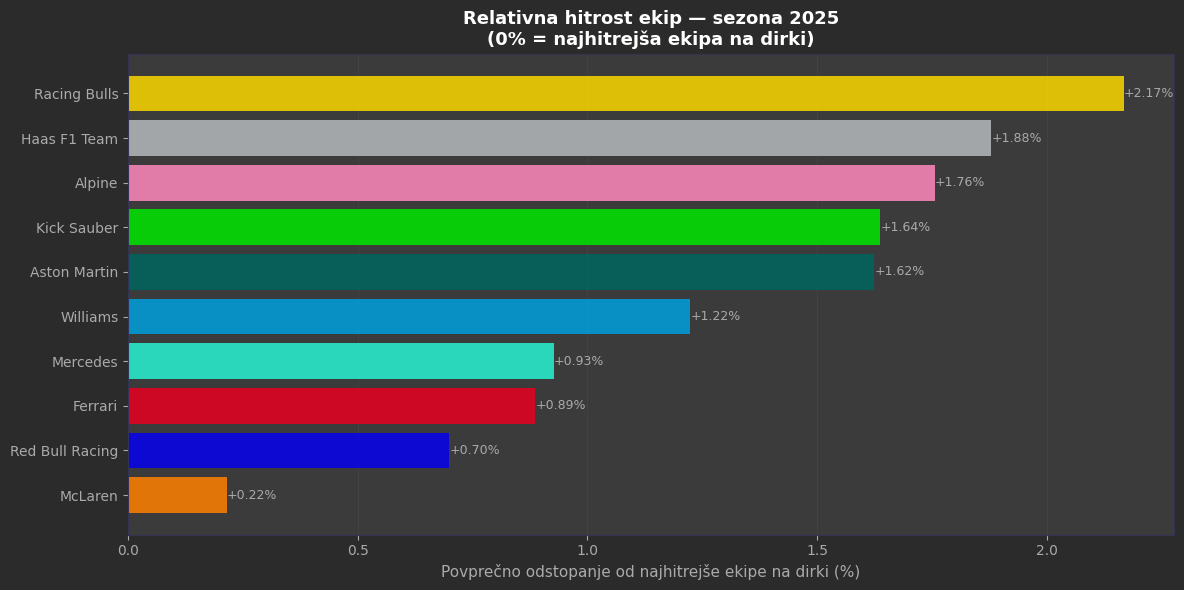

In [13]:
# Graf 3: Relativna hitrost ekip (brez dežja)
team_pace = (laps_dry
    .groupby(['Race', 'Team'])['LapTime_s']
    .min()
    .reset_index()
)

team_pace = team_pace.groupby('Race', group_keys=False).apply(normalize_laptime)

team_speed = (team_pace
    .groupby('Team')['LapTimePct']
    .mean()
    .sort_values()
    .reset_index()
)

colors_bar = [team_colors.get(t, '#888888') for t in team_speed['Team']]

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("#2B2B2B")
ax.set_facecolor("#3B3B3B")

bars = ax.barh(team_speed['Team'], team_speed['LapTimePct'],
               color=colors_bar, alpha=0.85, edgecolor='none')

for bar, val in zip(bars, team_speed['LapTimePct']):
    ax.text(val, bar.get_y() + bar.get_height()/2,
            f'+{val:.2f}%', va='center', fontsize=9, color='#aaaaaa')

ax.set_xlabel('Povprečno odstopanje od najhitrejše ekipe na dirki (%)',
              color='#aaaaaa', fontsize=11)
ax.set_title(f'Relativna hitrost ekip — sezona {SEASON}\n(0% = najhitrejša ekipa na dirki)',
             color='white', fontsize=13, fontweight='bold')
ax.tick_params(colors='#aaaaaa')
ax.spines[:].set_color('#333355')
ax.xaxis.grid(True, alpha=0.3, color='#555555')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


### Graf odstapanj ekip od najhitrejše ekipe sezone

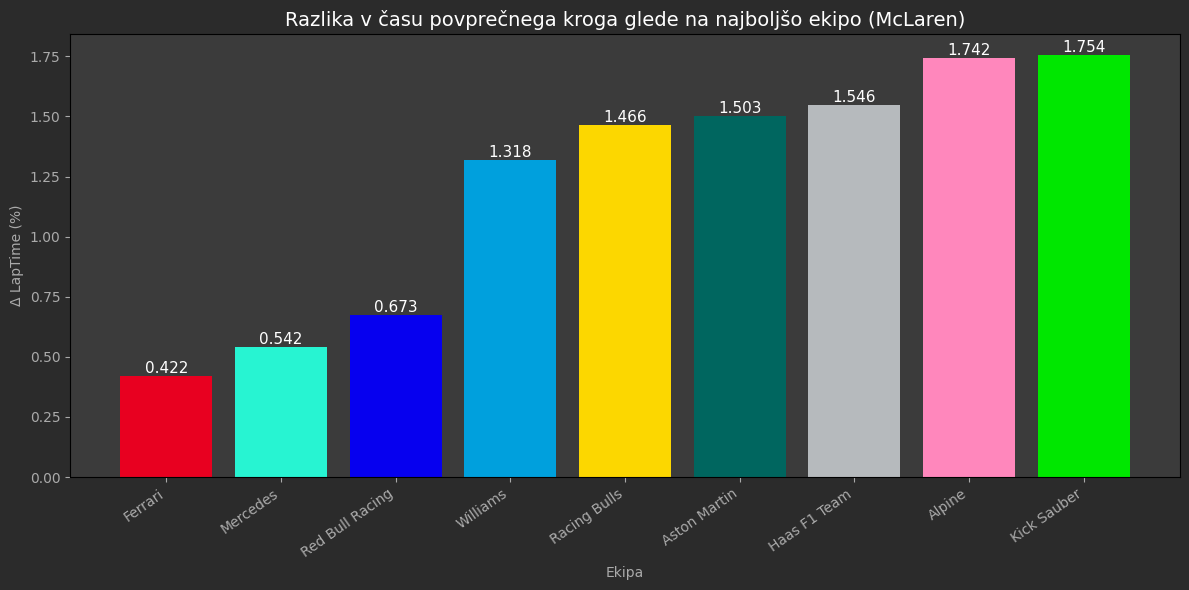

In [14]:
# Graf 4: Statistična analiza
best_team = team_order[0]
best_laps = laps_teams[laps_teams['Team'] == best_team]['LapTimePct'].values
best_med = np.median(best_laps)

team_medians = []
diffs = []
for team in team_order[1:]:
    laps = laps_teams[laps_teams['Team'] == team]['LapTimePct'].values
    med = np.median(laps)
    team_medians.append(med)
    diffs.append(med - best_med)

colors = [team_colors.get(t, '#888888') for t in team_order[1:]]

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(team_order[1:], diffs, color=colors)

for bar, val in zip(bars, diffs):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{val:.3f}",
        ha='center',
        va='bottom',
        fontsize=11,
        color='white'
    )

ax.set_title(f"Razlika v času povprečnega kroga glede na najboljšo ekipo ({best_team})",
             color='white', fontsize=14)
ax.set_ylabel("Δ LapTime (%)", color='#aaaaaa')
ax.set_xlabel("Ekipa", color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
plt.xticks(rotation=35, ha='right')

ax.set_facecolor("#3B3B3B")
fig.patch.set_facecolor("#2B2B2B")

plt.tight_layout()
plt.show()

In [15]:
# Statistična analiza (print)
print(f"\nPrimerjava z {best_team}\n")
print(f"{'Ekipa':<30} {'Mediana %':>10} {'do najboljšega':>20}")
for team in team_order:
    laps = laps_teams[laps_teams['Team'] == team]['LapTimePct'].values
    med = np.median(laps)
    dif = med - best_med
    print(f"{team:<30} {med:>10.3f} {dif:>20.3f}")


Primerjava z McLaren

Ekipa                           Mediana %       do najboljšega
McLaren                             2.507                0.000
Ferrari                             2.930                0.422
Mercedes                            3.049                0.542
Red Bull Racing                     3.181                0.673
Williams                            3.825                1.318
Racing Bulls                        3.973                1.466
Aston Martin                        4.010                1.503
Haas F1 Team                        4.054                1.546
Alpine                              4.250                1.742
Kick Sauber                         4.261                1.754
